In [1]:
ls

energy_cost_savings.py         power_10ms_apiserver.csv
fig_cost_by_region.pdf         power_10ms.csv
fig_cost_by_region.png         power_10ms_hybrid.csv
fig_cost_savings_vs_local.pdf  power_1s_1core.csv
fig_cost_savings_vs_local.png  power_1s_apiserver.csv
fig_energy_max_barplot.pdf     power_1s.csv
fig_energy_max_barplot.png     power_1s_hybrid.csv
fig_energy_p99_barplot.pdf     power_200ms_1core.csv
fig_energy_p99_barplot.png     power_200ms_apiserver.csv
fig_savings_grid_1000K.pdf     power_200ms.csv
fig_savings_grid_1000K.png     power_200ms_hybrid.csv
fig_savings_grid_100K.pdf      power_50ms_1core.csv
fig_savings_grid_100K.png      power_50ms_apiserver.csv
fig_savings_grid_500K.pdf      power_50ms.csv
fig_savings_grid_500K.png      power_50ms_hybrid.csv
power_100ms_1core.csv          power_top5_mean_barplot.pdf
power_100ms_apiserver.csv      power_top5_mean_barplot.png
power_100ms.csv                Untitled5.ipynb
power_100ms_hybrid.csv         Untitled.ipynb
power_10ms_1core.

=== Computing p99 ===

-- Hybrid --
  power_10ms_hybrid.csv: p99 = 203.4W  (n=6693)
  power_50ms_hybrid.csv: p99 = 157.2W  (n=6331)
  power_100ms_hybrid.csv: p99 = 143.5W  (n=5998)
  power_200ms_hybrid.csv: p99 = 138.6W  (n=6892)
  power_1s_hybrid.csv: p99 = 139.1W  (n=26343)

-- Local --
  power_10ms.csv: p99 = 143.9W  (n=6164)
  power_50ms.csv: p99 = 108.8W  (n=6294)
  power_100ms.csv: p99 = 106.0W  (n=5437)
  power_200ms.csv: p99 = 105.0W  (n=6512)
  power_1s.csv: p99 = 101.6W  (n=14488)

-- Local 1core --
  power_10ms_1core.csv: p99 = 136.8W  (n=6520)
  power_50ms_1core.csv: p99 = 103.1W  (n=6411)
  power_100ms_1core.csv: p99 = 101.3W  (n=5712)
  power_200ms_1core.csv: p99 = 101.2W  (n=8581)
  power_1s_1core.csv: p99 = 101.0W  (n=27716)

-- Local Apiserver --
  power_10ms_apiserver.csv: p99 = 128.8W  (n=6127)
  power_50ms_apiserver.csv: p99 = 102.9W  (n=7439)
  power_100ms_apiserver.csv: p99 = 101.5W  (n=9294)
  power_200ms_apiserver.csv: p99 = 102.7W  (n=30993)
  power_1s_apiserve

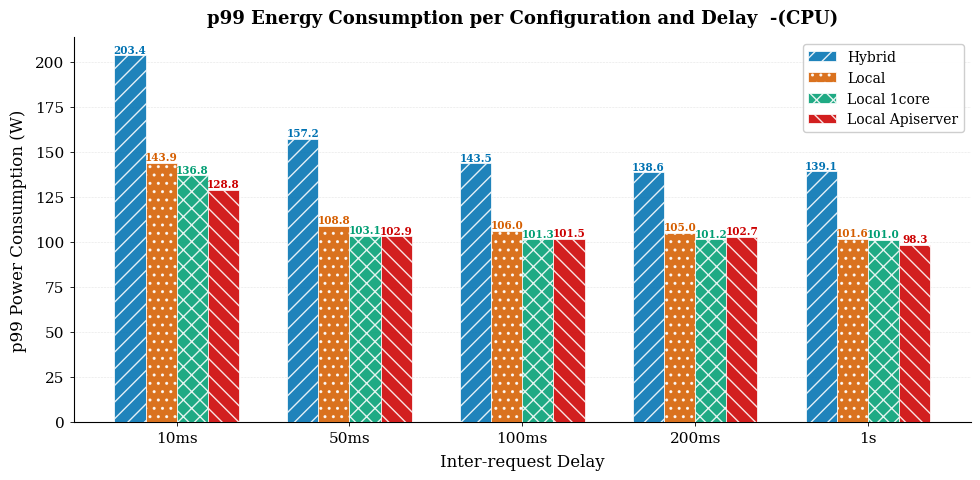

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         13,
    "axes.titlesize":    14,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

STYLES = {
    "Hybrid":           {"color": "#0072B2", "hatch": "//"},
    "Local":            {"color": "#D55E00", "hatch": ".."},
    "Local 1core":      {"color": "#009E73", "hatch": "xx"},
    "Local Apiserver":  {"color": "#CC0000", "hatch": "\\\\"},
}
ARCHS = list(STYLES.keys())

DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."

FILES = {
    "Local":           {
        "10ms":  "power_10ms.csv",
        "50ms":  "power_50ms.csv",
        "100ms": "power_100ms.csv",
        "200ms": "power_200ms.csv",
        "1s":    "power_1s.csv",
    },
    "Local 1core":     {
        "10ms":  "power_10ms_1core.csv",
        "50ms":  "power_50ms_1core.csv",
        "100ms": "power_100ms_1core.csv",
        "200ms": "power_200ms_1core.csv",
        "1s":    "power_1s_1core.csv",
    },
    "Hybrid":          {
        "10ms":  "power_10ms_hybrid.csv",
        "50ms":  "power_50ms_hybrid.csv",
        "100ms": "power_100ms_hybrid.csv",
        "200ms": "power_200ms_hybrid.csv",
        "1s":    "power_1s_hybrid.csv",
    },
    "Local Apiserver": {
        "10ms":  "power_10ms_apiserver.csv",
        "50ms":  "power_50ms_apiserver.csv",
        "100ms": "power_100ms_apiserver.csv",
        "200ms": "power_200ms_apiserver.csv",
        "1s":    "power_1s_apiserver.csv",
    },
}

POWER_COL = "Power_W"

def compute_p99(filepath, power_col=POWER_COL):
    if not os.path.exists(filepath):
        print(f"  [MISSING] {filepath}")
        return np.nan  # ← retourne nan au lieu de None
    try:
        df = pd.read_csv(filepath)
        if power_col not in df.columns:
            print(f"  [ERROR] Column '{power_col}' not found. Columns: {list(df.columns)}")
            return np.nan
        series = pd.to_numeric(df[power_col], errors='coerce').dropna()
        if len(series) == 0:
            print(f"  [EMPTY] {filepath}")
            return np.nan
        p99 = float(np.percentile(series.values, 99))
        print(f"  {os.path.basename(filepath)}: p99 = {p99:.1f}W  (n={len(series)})")
        return p99
    except Exception as e:
        print(f"  [ERROR] {filepath}: {e}")
        return np.nan  # ← retourne nan en cas d'erreur

# ── Build result matrix ───────────────────────────────────────────────────────
print("=== Computing p99 ===\n")
results = {arch: {} for arch in ARCHS}

for arch in ARCHS:
    print(f"-- {arch} --")
    for delay in DELAYS:
        path = os.path.join(DATA_DIR, FILES[arch][delay])
        results[arch][delay] = compute_p99(path)
    print()

# ── Plot ──────────────────────────────────────────────────────────────────────
n_delays = len(DELAYS)
n_archs  = len(ARCHS)
bar_width = 0.18
x = np.arange(n_delays)

fig, ax = plt.subplots(figsize=(10, 5))

for i, arch in enumerate(ARCHS):
    style  = STYLES[arch]
    values = np.array([results[arch].get(d, np.nan) for d in DELAYS], dtype=float)
    offset = (i - n_archs / 2 + 0.5) * bar_width

    for j, (val, delay) in enumerate(zip(values, DELAYS)):
        if np.isnan(val):
            continue  # ← skip missing values, no error
        bar = ax.bar(
            x[j] + offset,
            val,
            width=bar_width,
            label=arch if j == 0 else "_nolegend_",
            color=style["color"],
            hatch=style["hatch"],
            edgecolor="white",
            linewidth=0.6,
            alpha=0.88,
            zorder=3,
        )
        ax.text(
            x[j] + offset,
            val + 0.3,
            f"{val:.1f}",
            ha="center", va="bottom",
            fontsize=7.5, color=style["color"],
            fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(DELAYS, fontsize=11)
ax.set_xlabel("Inter-request Delay", fontsize=12, labelpad=6)
ax.set_ylabel("p99 Power Consumption (W)", fontsize=12, labelpad=6)
ax.set_title(
    "p99 Energy Consumption per Configuration and Delay  -(CPU)",
    fontsize=13, fontweight="bold", pad=10
)
ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.80", zorder=0)
ax.grid(False, axis="x")
ax.tick_params(axis="both", direction="out", length=3, width=0.6)
ax.legend(loc="upper right", fontsize=10, framealpha=0.95, edgecolor="0.80")

plt.tight_layout()
fig.savefig("fig_energy_p99_barplot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_energy_p99_barplot.png", dpi=300, bbox_inches="tight")
print("✓ Saved: fig_energy_p99_barplot.pdf / .png")

=== Computing MAX power ===

-- Hybrid --
  power_10ms_hybrid.csv: max = 215.8W
  power_50ms_hybrid.csv: max = 157.2W
  power_100ms_hybrid.csv: max = 143.5W
  power_200ms_hybrid.csv: max = 141.0W
  power_1s_hybrid.csv: max = 191.6W

-- Local --
  power_10ms.csv: max = 146.5W
  power_50ms.csv: max = 116.0W
  power_100ms.csv: max = 106.0W
  power_200ms.csv: max = 105.8W
  power_1s.csv: max = 102.5W

-- Local 1core --
  power_10ms_1core.csv: max = 138.0W
  power_50ms_1core.csv: max = 103.1W
  power_100ms_1core.csv: max = 101.3W
  power_200ms_1core.csv: max = 101.2W
  power_1s_1core.csv: max = 101.2W

-- Local Apiserver --
  power_10ms_apiserver.csv: max = 143.2W
  power_50ms_apiserver.csv: max = 102.9W
  power_100ms_apiserver.csv: max = 101.5W
  power_200ms_apiserver.csv: max = 102.7W
  power_1s_apiserver.csv: max = 98.3W

✓ Saved: fig_energy_max_barplot.pdf / .png


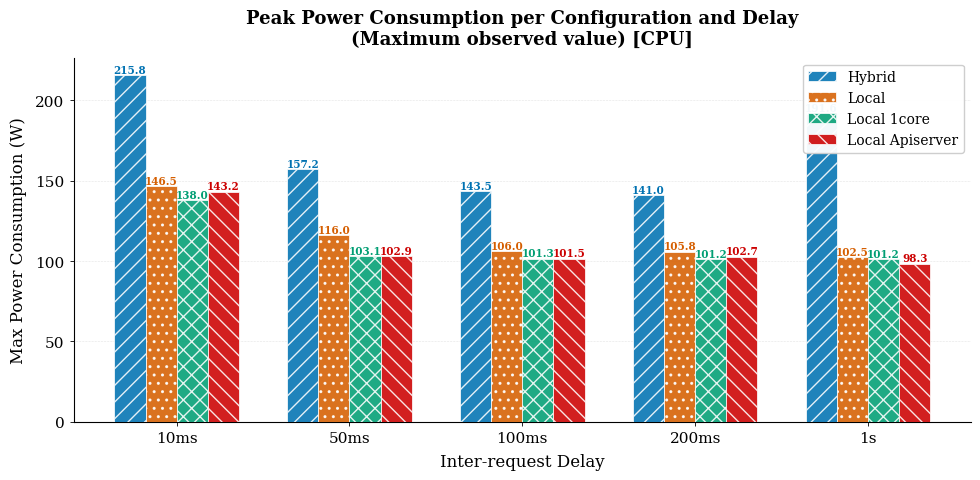

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         13,
    "axes.titlesize":    14,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

STYLES = {
    "Hybrid":           {"color": "#0072B2", "hatch": "//"},
    "Local":            {"color": "#D55E00", "hatch": ".."},
    "Local 1core":      {"color": "#009E73", "hatch": "xx"},
    "Local Apiserver":  {"color": "#CC0000", "hatch": "\\\\"},
}
ARCHS  = list(STYLES.keys())
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."

FILES = {
    "Local":           {d: f"power_{d}.csv"           for d in DELAYS},
    "Local 1core":     {d: f"power_{d}_1core.csv"     for d in DELAYS},
    "Hybrid":          {d: f"power_{d}_hybrid.csv"    for d in DELAYS},
    "Local Apiserver": {d: f"power_{d}_apiserver.csv" for d in DELAYS},
}
POWER_COL = "Power_W"

def compute_max(filepath, power_col=POWER_COL):
    if not os.path.exists(filepath):
        print(f"  [MISSING] {filepath}")
        return np.nan
    try:
        df = pd.read_csv(filepath)
        if power_col not in df.columns:
            print(f"  [ERROR] Column '{power_col}' not found. Columns: {list(df.columns)}")
            return np.nan
        series = pd.to_numeric(df[power_col], errors='coerce').dropna()
        if len(series) == 0:
            return np.nan
        max_val = float(series.max())
        print(f"  {os.path.basename(filepath)}: max = {max_val:.1f}W")
        return max_val
    except Exception as e:
        print(f"  [ERROR] {filepath}: {e}")
        return np.nan

# ── Build results ─────────────────────────────────────────────────────────────
print("=== Computing MAX power ===\n")
results = {arch: {} for arch in ARCHS}
for arch in ARCHS:
    print(f"-- {arch} --")
    for delay in DELAYS:
        path = os.path.join(DATA_DIR, FILES[arch][delay])
        results[arch][delay] = compute_max(path)
    print()

# ── Plot ──────────────────────────────────────────────────────────────────────
x         = np.arange(len(DELAYS))
bar_width = 0.18
fig, ax   = plt.subplots(figsize=(10, 5))

for i, arch in enumerate(ARCHS):
    style  = STYLES[arch]
    offset = (i - len(ARCHS) / 2 + 0.5) * bar_width
    for j, delay in enumerate(DELAYS):
        val = results[arch].get(delay, np.nan)
        if np.isnan(val):
            continue
        ax.bar(
            x[j] + offset, val,
            width=bar_width,
            label=arch if j == 0 else "_nolegend_",
            color=style["color"],
            hatch=style["hatch"],
            edgecolor="white",
            linewidth=0.6,
            alpha=0.88,
            zorder=3,
        )
        ax.text(
            x[j] + offset, val + 0.3,
            f"{val:.1f}",
            ha="center", va="bottom",
            fontsize=7.5, color=style["color"], fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(DELAYS, fontsize=11)
ax.set_xlabel("Inter-request Delay", fontsize=12, labelpad=6)
ax.set_ylabel("Max Power Consumption (W)", fontsize=12, labelpad=6)
ax.set_title(
    "Peak Power Consumption per Configuration and Delay\n(Maximum observed value) [CPU]",
    fontsize=13, fontweight="bold", pad=10
)
ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.80", zorder=0)
ax.grid(False, axis="x")
ax.tick_params(axis="both", direction="out", length=3, width=0.6)
ax.legend(loc="upper right", fontsize=10, framealpha=0.95, edgecolor="0.80")

plt.tight_layout()
fig.savefig("fig_energy_max_barplot.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_energy_max_barplot.png", dpi=300, bbox_inches="tight")
print("✓ Saved: fig_energy_max_barplot.pdf / .png")

=== Computing max power ===

-- Hybrid --
  10ms: 215.8W
  50ms: 157.2W
  100ms: 143.5W
  200ms: 141.0W
  1s: 191.6W

-- Local --
  10ms: 146.5W
  50ms: 116.0W
  100ms: 106.0W
  200ms: 105.8W
  1s: 102.5W

-- Local 1core --
  10ms: 138.0W
  50ms: 103.1W
  100ms: 101.3W
  200ms: 101.2W
  1s: 101.2W

-- Local Apiserver --
  10ms: 143.2W
  50ms: 102.9W
  100ms: 101.5W
  200ms: 102.7W
  1s: 98.3W

Mean max power per config:
  Hybrid: 169.8W
  Local: 115.4W
  Local 1core: 109.0W
  Local Apiserver: 109.7W

✓ Saved: fig_cost_by_region.pdf / .png
✓ Saved: fig_cost_savings_vs_local.pdf / .png

=== Summary Table ===
Config                Mean Max Power   N. Virginia @ 1M servers  Ireland @ 1M servers  Singapore @ 1M servers
------------------------------------------------------------------------------------------
Hybrid                        169.8W   $161.4M (saving: -51.8M)  €204.4M (saving: -65.5M)  S$324.9M (saving: -104.2M)
Local                         115.4W   $109.6M (saving: +0.0M)  €13

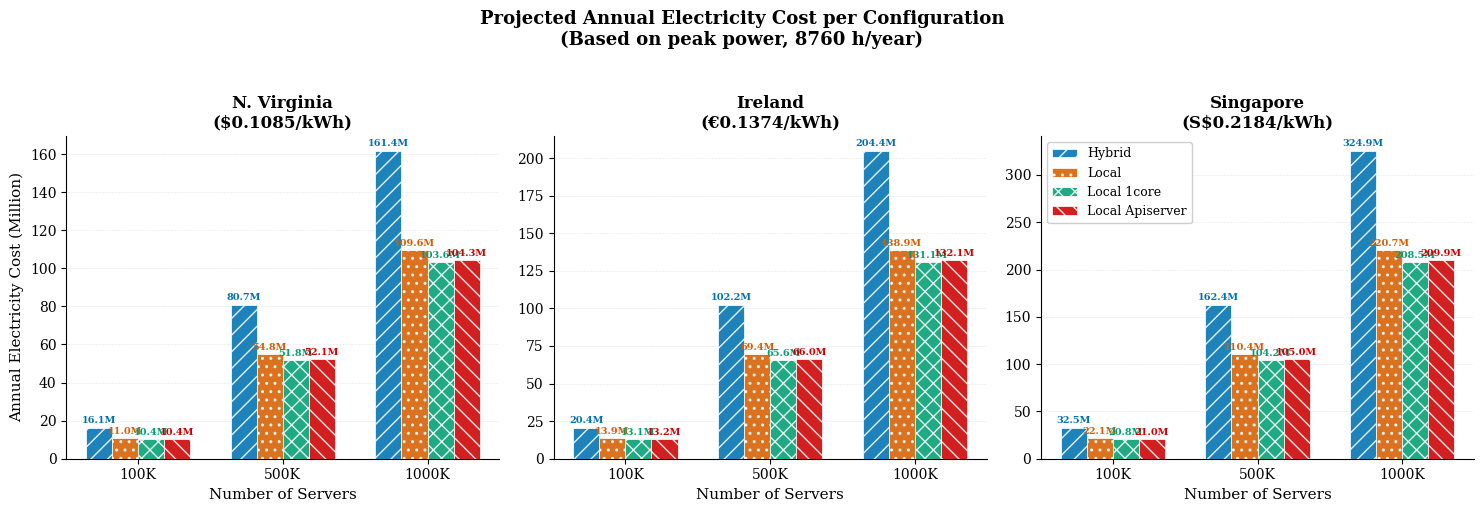

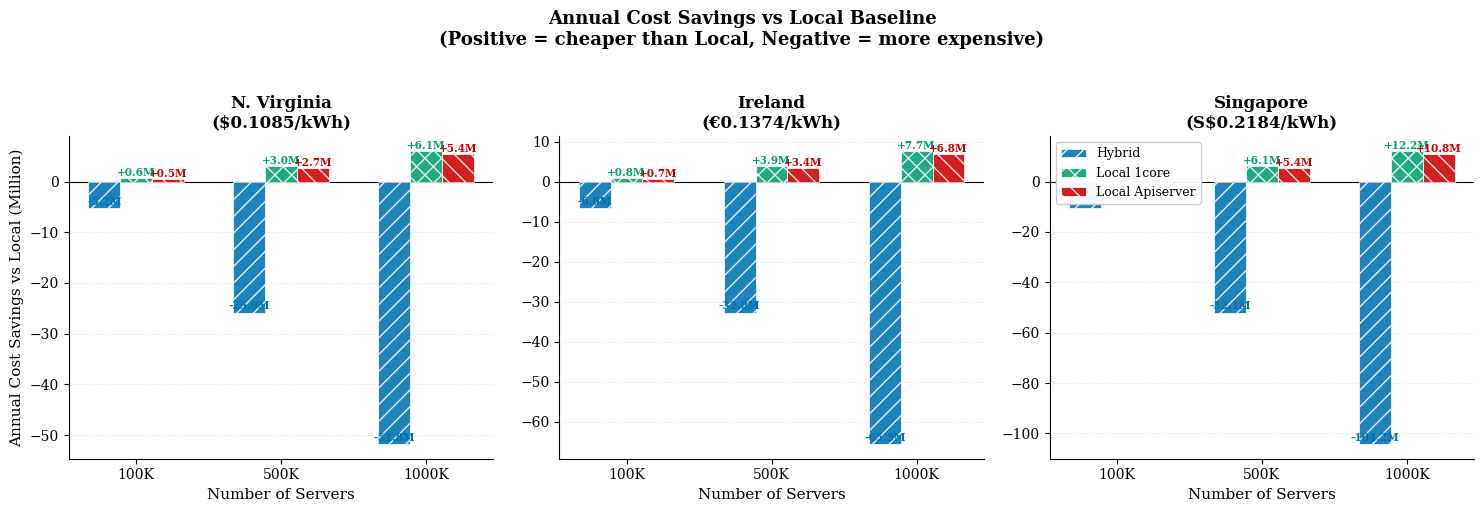

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         12,
    "axes.titlesize":    13,
    "axes.labelsize":    12,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Regions & pricing ─────────────────────────────────────────────────────────
REGIONS = {
    'virginia':  {'name': 'N. Virginia', 'price_per_kwh': 0.1085, 'currency': '$'},
    'ireland':   {'name': 'Ireland',     'price_per_kwh': 0.1374, 'currency': '€'},
    'singapore': {'name': 'Singapore',   'price_per_kwh': 0.2184, 'currency': 'S$'},
}

DATACENTER_SCALES = [100_000, 500_000, 1_000_000]  # number of servers
HOURS_PER_YEAR    = 8760

# ── Configurations & palette ──────────────────────────────────────────────────
STYLES = {
    "Hybrid":           {"color": "#0072B2", "hatch": "//"},
    "Local":            {"color": "#D55E00", "hatch": ".."},
    "Local 1core":      {"color": "#009E73", "hatch": "xx"},
    "Local Apiserver":  {"color": "#CC0000", "hatch": "\\\\"},
}
ARCHS  = list(STYLES.keys())
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."

FILES = {
    "Local":           {d: f"power_{d}.csv"           for d in DELAYS},
    "Local 1core":     {d: f"power_{d}_1core.csv"     for d in DELAYS},
    "Hybrid":          {d: f"power_{d}_hybrid.csv"    for d in DELAYS},
    "Local Apiserver": {d: f"power_{d}_apiserver.csv" for d in DELAYS},
}
POWER_COL = "Power_W"

# ── Helper: compute max power ─────────────────────────────────────────────────
def compute_max(filepath, power_col=POWER_COL):
    if not os.path.exists(filepath):
        return np.nan
    try:
        df     = pd.read_csv(filepath)
        series = pd.to_numeric(df[power_col], errors='coerce').dropna()
        return float(series.max()) if len(series) > 0 else np.nan
    except Exception:
        return np.nan

# ── Helper: annual cost ───────────────────────────────────────────────────────
def annual_cost(power_w, price_per_kwh, n_servers):
    """
    power_w       : peak power in Watts for ONE server/cluster unit
    price_per_kwh : electricity price in $/€/S$ per kWh
    n_servers     : datacenter scale
    Returns annual cost in dollars/euros
    """
    energy_kwh_per_year = (power_w / 1000) * HOURS_PER_YEAR
    return energy_kwh_per_year * price_per_kwh * n_servers

# ── Build power matrix ────────────────────────────────────────────────────────
print("=== Computing max power ===\n")
power = {arch: {} for arch in ARCHS}
for arch in ARCHS:
    print(f"-- {arch} --")
    for delay in DELAYS:
        path = os.path.join(DATA_DIR, FILES[arch][delay])
        val  = compute_max(path)
        power[arch][delay] = val
        if not np.isnan(val):
            print(f"  {delay}: {val:.1f}W")
    print()

# ── Figure 1 — Annual cost per region × scale (averaged over delays) ──────────
# Use mean max power across delays as representative value per config
mean_power = {
    arch: np.nanmean(list(power[arch].values()))
    for arch in ARCHS
}
print("Mean max power per config:")
for arch, p in mean_power.items():
    print(f"  {arch}: {p:.1f}W")

n_regions = len(REGIONS)
n_scales  = len(DATACENTER_SCALES)
fig, axes = plt.subplots(1, n_regions, figsize=(5 * n_regions, 5), sharey=False)

for ci, (region_key, region) in enumerate(REGIONS.items()):
    ax = axes[ci]
    x  = np.arange(n_scales)
    bar_width = 0.18

    for i, arch in enumerate(ARCHS):
        p      = mean_power[arch]
        if np.isnan(p):
            continue
        costs  = [annual_cost(p, region['price_per_kwh'], s) / 1e6 for s in DATACENTER_SCALES]
        offset = (i - len(ARCHS) / 2 + 0.5) * bar_width
        style  = STYLES[arch]

        bars = ax.bar(
            x + offset, costs,
            width=bar_width,
            label=arch,
            color=style["color"],
            hatch=style["hatch"],
            edgecolor="white",
            linewidth=0.6,
            alpha=0.88,
            zorder=3,
        )
        for bar, cost in zip(bars, costs):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01 * max(costs),
                f"{cost:.1f}M",
                ha="center", va="bottom",
                fontsize=7, color=style["color"], fontweight="bold",
            )

    ax.set_title(f"{region['name']}\n({region['currency']}{region['price_per_kwh']}/kWh)",
                 fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s//1000}K" for s in DATACENTER_SCALES], fontsize=10)
    ax.set_xlabel("Number of Servers", fontsize=11)
    if ci == 0:
        ax.set_ylabel("Annual Electricity Cost (Million)", fontsize=11)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.80", zorder=0)
    ax.grid(False, axis="x")
    if ci == n_regions - 1:
        ax.legend(loc="upper left", fontsize=9, framealpha=0.95)

fig.suptitle("Projected Annual Electricity Cost per Configuration\n(Based on peak power, 8760 h/year)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("fig_cost_by_region.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_cost_by_region.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved: fig_cost_by_region.pdf / .png")

# ── Figure 2 — Savings vs Local baseline ──────────────────────────────────────
# For each config, compute savings vs Local baseline
baseline_power = mean_power["Local"]

fig2, axes2 = plt.subplots(1, n_regions, figsize=(5 * n_regions, 5), sharey=False)

for ci, (region_key, region) in enumerate(REGIONS.items()):
    ax = axes2[ci]
    x  = np.arange(n_scales)
    bar_width = 0.22

    non_baseline = [a for a in ARCHS if a != "Local"]

    for i, arch in enumerate(non_baseline):
        p = mean_power[arch]
        if np.isnan(p):
            continue
        savings = [
            (annual_cost(baseline_power, region['price_per_kwh'], s) -
             annual_cost(p, region['price_per_kwh'], s)) / 1e6
            for s in DATACENTER_SCALES
        ]
        offset = (i - len(non_baseline) / 2 + 0.5) * bar_width
        style  = STYLES[arch]

        bars = ax.bar(
            x + offset, savings,
            width=bar_width,
            label=arch,
            color=style["color"],
            hatch=style["hatch"],
            edgecolor="white",
            linewidth=0.6,
            alpha=0.88,
            zorder=3,
        )
        for bar, s_val in zip(bars, savings):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.005 * abs(max(savings, key=abs))),
                f"{s_val:+.1f}M",
                ha="center", va="bottom",
                fontsize=7.5, color=style["color"], fontweight="bold",
            )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.set_title(f"{region['name']}\n({region['currency']}{region['price_per_kwh']}/kWh)",
                 fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s//1000}K" for s in DATACENTER_SCALES], fontsize=10)
    ax.set_xlabel("Number of Servers", fontsize=11)
    if ci == 0:
        ax.set_ylabel("Annual Cost Savings vs Local (Million)", fontsize=11)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.80", zorder=0)
    ax.grid(False, axis="x")
    if ci == n_regions - 1:
        ax.legend(loc="upper left", fontsize=9, framealpha=0.95)

fig2.suptitle("Annual Cost Savings vs Local Baseline\n(Positive = cheaper than Local, Negative = more expensive)",
              fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig2.savefig("fig_cost_savings_vs_local.pdf", dpi=300, bbox_inches="tight")
fig2.savefig("fig_cost_savings_vs_local.png", dpi=300, bbox_inches="tight")
print("✓ Saved: fig_cost_savings_vs_local.pdf / .png")

# ── Print summary table ───────────────────────────────────────────────────────
print("\n=== Summary Table ===")
print(f"{'Config':<20} {'Mean Max Power':>15} ", end="")
for r in REGIONS.values():
    print(f"  {r['name']} @ 1M servers", end="")
print()
print("-" * 90)
for arch in ARCHS:
    p = mean_power[arch]
    print(f"{arch:<20} {p:>14.1f}W ", end="")
    for r in REGIONS.values():
        cost = annual_cost(p, r['price_per_kwh'], 1_000_000) / 1e6
        saving = (annual_cost(baseline_power, r['price_per_kwh'], 1_000_000) -
                  annual_cost(p, r['price_per_kwh'], 1_000_000)) / 1e6
        print(f"  {r['currency']}{cost:.1f}M (saving: {saving:+.1f}M)", end="")
    print()